In [137]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import h5py
import inspect
from tqdm import tqdm
import sys
import math
import glob
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.constants import Planck

# style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['axes.labelsize'] = 17
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 17
plt.rcParams['legend.frameon'] = False

In [138]:
# Load Exp Data
def load_ExpData(file_, idx_str_):
    # Open hdf5 file
    with h5py.File(file_, "r") as dataset:
        # Data
        return dict(freq_comb=np.asarray(dataset[idx_str_]["freq comb"]),
                    freq_pump=np.asarray(dataset[idx_str_]["freq pumps"]),
                    pump_pwr_data=np.asarray(dataset[idx_str_]["pump pwr sweep"]),
                    pump_phase_data=np.asarray(dataset[idx_str_]["pump phase sweep"]),
                    df=np.asarray(dataset[idx_str_]["df"]),
                    USB=np.asarray(dataset[idx_str_]["USB"]),
                    )

## Extract quadrature data

In [ ]:

folder = "/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/LKIPA Measurements/I:/LKiPA-Data/2026-04/Covariance"

# Get all HDF5 files in the folder
files = glob.glob(os.path.join(folder, "*.hdf5"))

# Pick the most recently modified one
file = files[-12]  # max(files, key=os.path.getmtime)

print("Selected file:", file)

# Extract the run name automatically
run = os.path.basename(file).replace(".hdf5", "")
print("Run:", run)

Selected file: /home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/LKIPA Measurements/I:/LKiPA-Data/2026-04/Covariance/2026-04-15_16_39_30.hdf5
Run: 2026-04-15_16_39_30


In [140]:
usb = load_ExpData(
    file_ = file,
    idx_str_= run
    )['USB']
usb=np.array(usb)

freqs = load_ExpData(
    file_ = file,
    idx_str_= run
    )['freq_comb']

# Attributes for saving figures
modes = int(len(freqs))         # NUMBER OF MODES
print('Modes = ' + str(modes))

p_amp =load_ExpData( # Pump power in FS units
    file_ = file,
    idx_str_= run
    )['pump_pwr_data'] 

print('Pump Power = ' + str(p_amp))

fp = load_ExpData(                    # PUMP POWER
    file_ = file,
    idx_str_= run
    )['freq_pump'][0] / 1e9
print('Pump Frequency  = ' + str(fp) + 'GHz')


df = int(load_ExpData(                    # PUMP POWER
    file_ = file,
    idx_str_= run
    )['df']
)
print('df = ' + str(df//1e3) + 'kHz')

Modes = 45
Pump Power = 0.08
Pump Frequency  = 8.857GHz
df = 10.0kHz


## Create covariance matrix

In [141]:
def covariance_matrix(usb_arr):
    real_part = np.real(usb_arr)
    imag_part = np.imag(usb_arr)

    # Stack quadratures: [Re0, Im0, Re1, Im1, ...]
    xp_mat = np.empty((usb_arr.shape[0], usb_arr.shape[1]*2))
    xp_mat[:, 0::2] = real_part
    xp_mat[:, 1::2] = imag_part

    # Covariance over samples
    return np.cov(xp_mat, rowvar=False)

def cov_rotation(cov_mat, theta):
    """Rotate covariance matrix by angle theta (radians)"""
    c, s = np.cos(theta), np.sin(theta)
    R = np.array(
        [[c, -s],
        [s, c]]
    )
    
    N = cov_mat.shape[0] // 2
    R_big = np.zeros((2*N, 2*N))
    for i in range(N):
        R_big[2*i:2*i+2, 2*i:2*i+2] = R
    
    return R_big @ cov_mat @ R_big.T


## Conversion to photon number

In [142]:
FS_to_V2 = 0.56

gain_dB = 56.175  # dB

gain_signal = 10 ** (gain_dB/10)

Z_line = 50 # Ohms

freq_comb = freqs + 4.31e9

scale = np.sqrt(FS_to_V2 / (Planck * gain_signal * Z_line * freqs * df))

usb_arr_scaled = usb * scale 

cov_mat = covariance_matrix(usb_arr_scaled)

## Plot

[Text(0, 4.5, '-20'),
 Text(0, 14.5, '-15'),
 Text(0, 24.5, '-10'),
 Text(0, 34.5, '-5'),
 Text(0, 44.5, '0'),
 Text(0, 54.5, '5'),
 Text(0, 64.5, '10'),
 Text(0, 74.5, '15'),
 Text(0, 84.5, '20')]

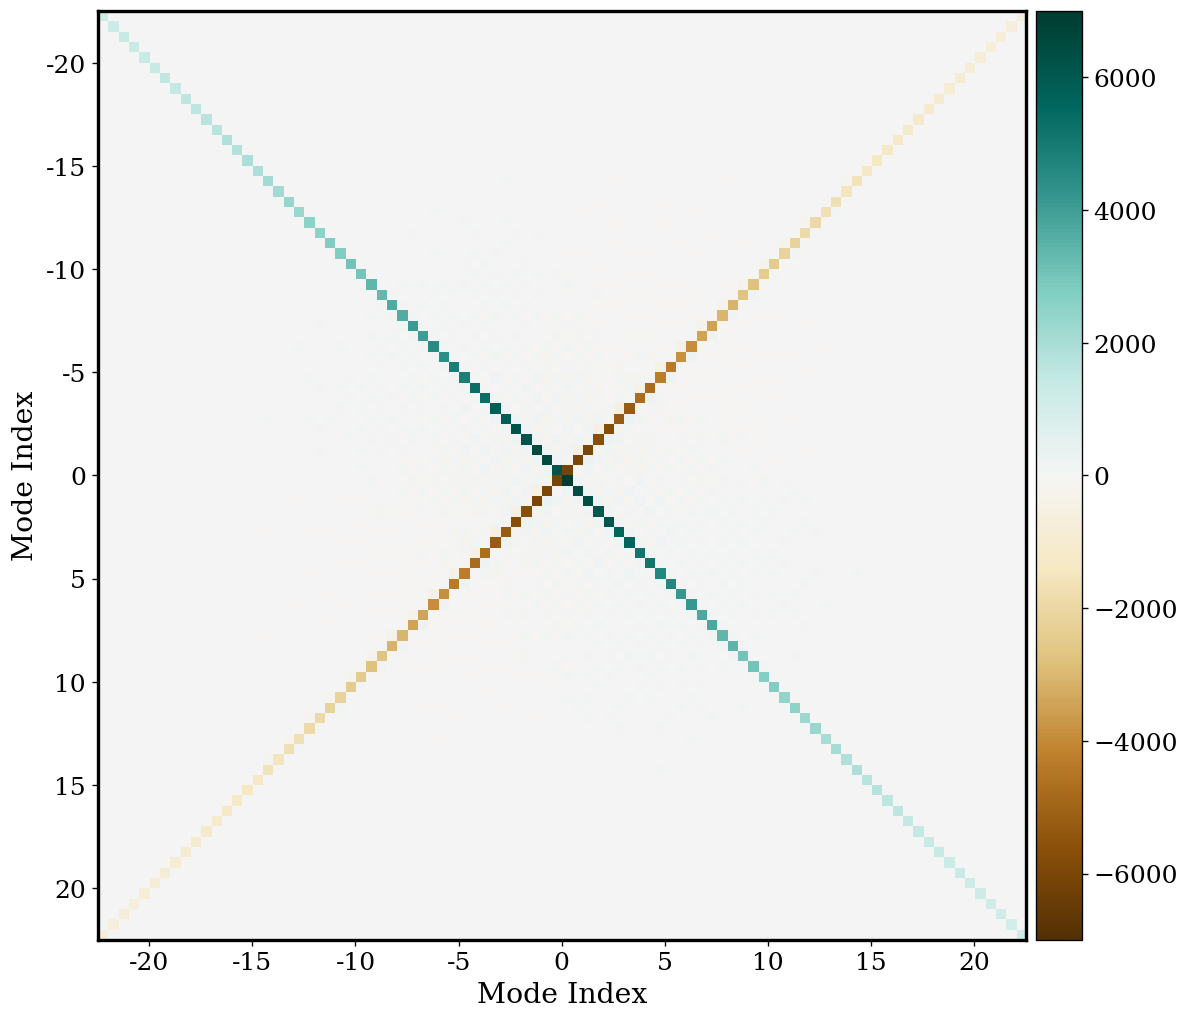

In [146]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(9, 9), dpi=120)

theta = 0.2* np.pi
cov_mat_rot = cov_rotation(cov_mat, theta)

max_cov = np.max(cov_mat_rot)
min_cov = -max_cov

im = ax.imshow(
    cov_mat_rot,
    aspect='equal',
    cmap='BrBG',
    origin='upper',
    vmax=max_cov,
    vmin=min_cov
)

# Colorbar exactly as tall as the matrix
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.08)
cbar = fig.colorbar(im, cax=cax)

ax.set_xlabel("Mode Index")
ax.set_ylabel("Mode Index")

for spine in ax.spines.values():
    spine.set_linewidth(2)

# Tick labels: 0 at centre, ±(modes-1)/2 at edges, step of 5
mode_half = (modes - 1) / 2          # = 22.0 for 45 modes
step = 5
max_label = (int(mode_half) // step) * step   # largest multiple of 5 within range
mode_labels = np.arange(-max_label, max_label + 1, step)  # e.g. [-20, -15, ..., 0, ..., 20]
tick_positions = 2 * (mode_labels + mode_half) + 0.5      # centre of each mode's 2-cell block

ax.set_xticks(tick_positions)
ax.set_xticklabels(mode_labels)
ax.set_yticks(tick_positions)
ax.set_yticklabels(mode_labels)

# plt.savefig(
#     fname=f'Figures/Covariance/LKIPA-Cov-modes={modes}-df={df}-run={run}-1pump_amp={p_amp}-pixels=1M.png'
# )

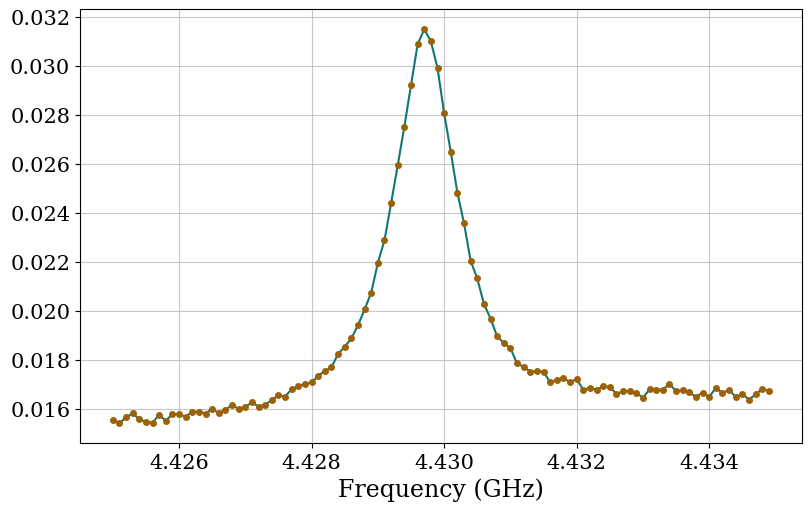

In [144]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
# Define colors
color_a = '#9d6108'  # Example: Red
color_b = '#12776f'  # Example: Blue
color_c = '#a9ccc7'

# Create custom colormap
cmap_name = 'my_list'
custom_cmap = mcolors.LinearSegmentedColormap.from_list(cmap_name, [color_a, color_c, color_b])

# Load PSD data
psd_list = np.loadtxt('/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/LKIPA Measurements/Time series data/LKIPA-PSD-df=100khz-pixels=20000.txt')

# Frequency array for PSD
df = 100e3  # Frequency resolution in Hz
n_samples = len(psd_list)
freq_arr = np.arange(n_samples) * df

# Freq range of interest
f_min = 0.425e9  # 0.42 GHz
f_max = 0.435e9  # 0.44 GHz
indices = np.arange(f_min/1e5, f_max/1e5).astype(int)

freq_band =  4 + freq_arr[indices]/1e9
psd_band = psd_list[indices]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freq_band, psd_band, color = color_b, marker = 'o', ms=4, mfc = color_a, mec = color_a)
ax.set_xlabel('Frequency (GHz)')
ax.grid(alpha=0.7)

[Text(0, 4.5, '-20'),
 Text(0, 14.5, '-15'),
 Text(0, 24.5, '-10'),
 Text(0, 34.5, '-5'),
 Text(0, 44.5, '0'),
 Text(0, 54.5, '5'),
 Text(0, 64.5, '10'),
 Text(0, 74.5, '15'),
 Text(0, 84.5, '20')]

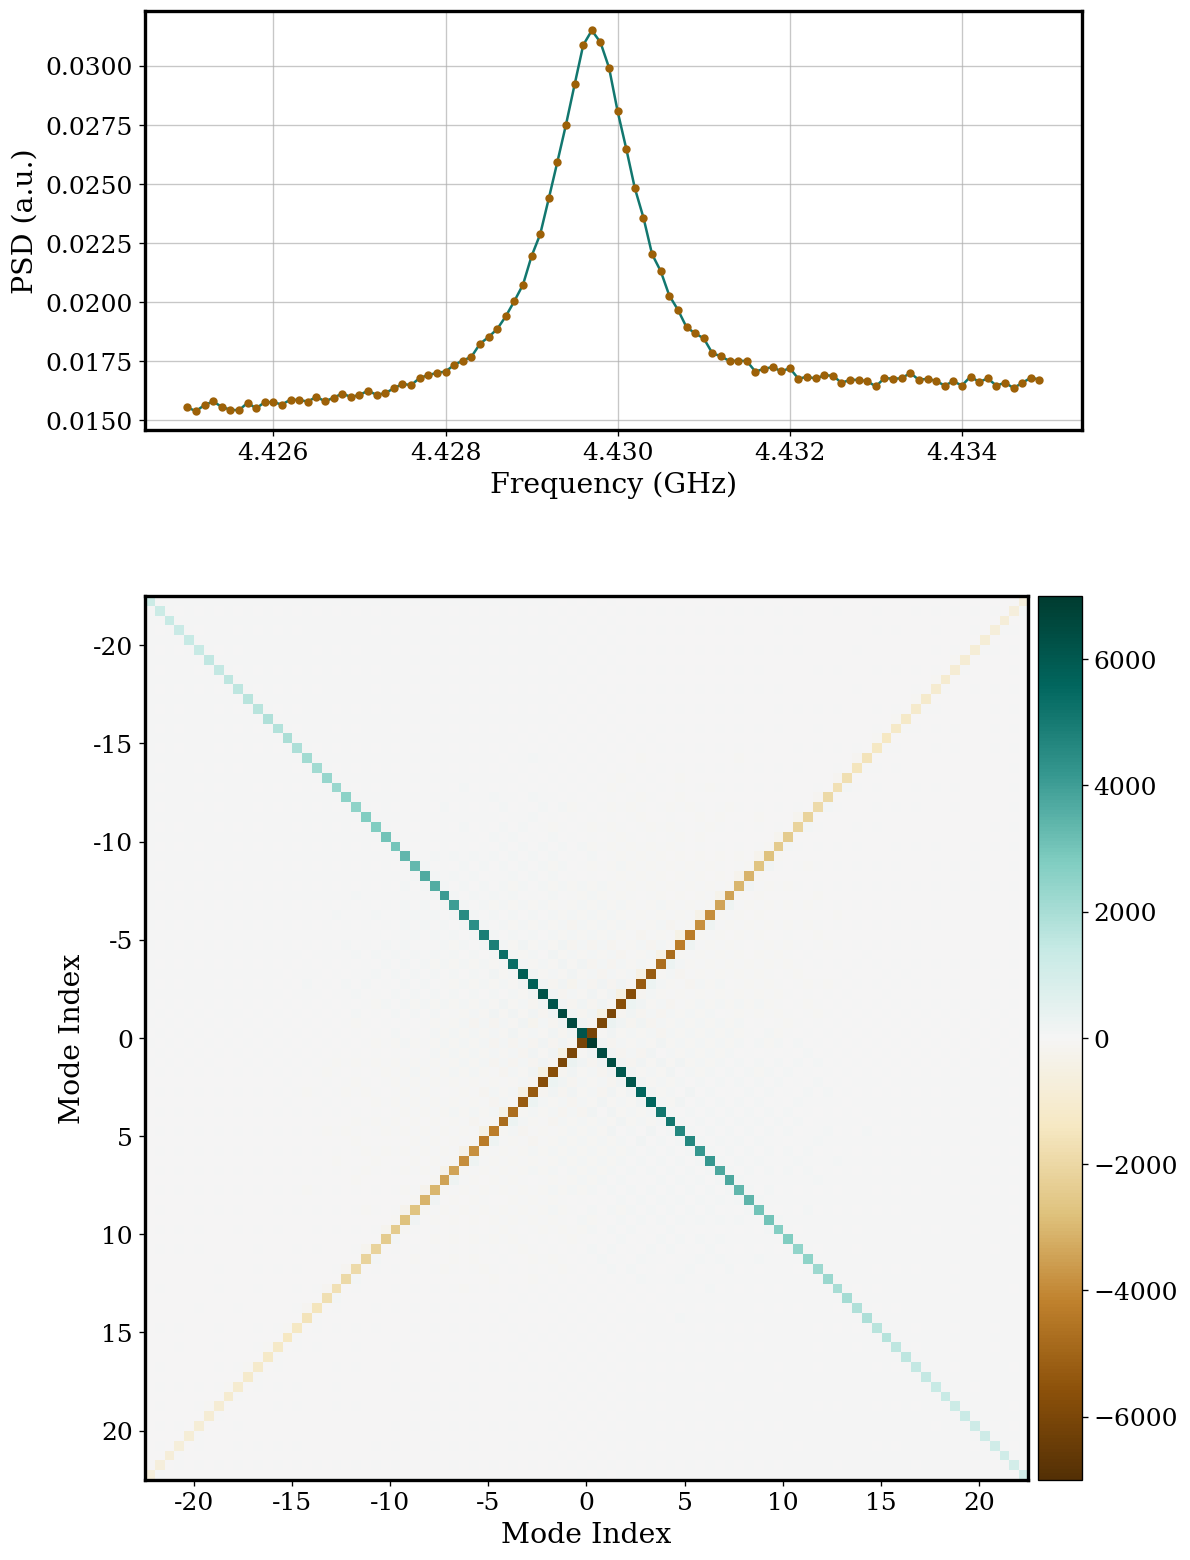

In [147]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, (ax_psd, ax_cov) = plt.subplots(2, 1, figsize=(9, 13), dpi=120,
                                      gridspec_kw={'height_ratios': [1, 2.5]})
#fig.subplots_adjust(hspace=0.25)

# ── Row 1: PSD band ──────────────────────────────────────────────────────────
ax_psd.plot(freq_band, psd_band, color=color_b, marker='o', ms=4, mfc=color_a, mec=color_a)
ax_psd.set_xlabel('Frequency (GHz)')
ax_psd.set_ylabel('PSD (a.u.)')
ax_psd.grid(alpha=0.7)
for spine in ax_psd.spines.values():
    spine.set_linewidth(2)

# ── Row 2: Covariance matrix ─────────────────────────────────────────────────
theta = 0.2 * np.pi
cov_mat_rot = cov_rotation(cov_mat, theta)

max_cov = np.max(cov_mat_rot)
min_cov = -max_cov

im = ax_cov.imshow(
    cov_mat_rot,
    aspect='equal',
    cmap='BrBG',
    origin='upper',
    vmax=max_cov,
    vmin=min_cov,
)

divider = make_axes_locatable(ax_cov)
cax = divider.append_axes("right", size="5%", pad=0.08)
fig.colorbar(im, cax=cax)

ax_cov.set_xlabel("Mode Index")
ax_cov.set_ylabel("Mode Index")
for spine in ax_cov.spines.values():
    spine.set_linewidth(2)

mode_half = (modes - 1) / 2
step = 5
max_label = (int(mode_half) // step) * step
mode_labels = np.arange(-max_label, max_label + 1, step)
tick_positions = 2 * (mode_labels + mode_half) + 0.5

ax_cov.set_xticks(tick_positions)
ax_cov.set_xticklabels(mode_labels)
ax_cov.set_yticks(tick_positions)
ax_cov.set_yticklabels(mode_labels)
